# Random Fourier Features → SSGP → VSSGP — Three Spectral Views of a Gaussian Process

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/random_fourier_features.ipynb)

This notebook is the **GP-flavored** companion to the [RFF as Neural Networks notebook](rff_as_neural_networks.ipynb). Where that notebook treats RFF as a neural network architecture (with frozen, learned, or ensembled weights), here we follow the *Bayesian* progression that links the same feature map to Gaussian processes:

1. **Learned RFF (MAP baseline)** — the deterministic regression model with trainable $\Omega$. No uncertainty over the parameters; just a regularised MSE point estimate.
2. **SSGP — Sparse Spectrum GP** (Lázaro-Gredilla et al. JMLR 2010) — analytically *marginalise* the head $\beta$ and train $\Omega$ on the **GP marginal likelihood**. Closed-form predictive variance for free.
3. **VSSGP — Variational SSGP** (Gal & Turner ICML 2015) — put a **variational posterior** $q(\Omega)$ on top of $q(\beta)$, train via reparameterised ELBO. Full posterior uncertainty over both frequencies and weights.

The three are different inferential commitments to the **same model class** — a linear combination of $M$ random Fourier features:

$$y_i = \Phi(x_i; \Omega)\,\beta + \varepsilon_i, \qquad \Phi(x; \Omega) = \sqrt{\tfrac{1}{M}}\bigl[\cos(\Omega^\top x), \sin(\Omega^\top x)\bigr] \in \mathbb{R}^{2M}, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma_n^2).$$

| Method | $\Omega$ | $\beta$ | Objective | Predictive variance? |
|---|---|---|---|---|
| **Learned RFF (MAP)** | trained (point) | trained (point) + L2 | regularised MSE | no |
| **SSGP** | trained (point) | marginalised analytically | log marginal likelihood | yes — closed form |
| **VSSGP** | variational $q(\Omega)$ | variational $q(\beta)$ | tempered ELBO | yes — MC over the posterior |

Forward-pointers: the **fixed-Ω** version (Rahimi-Recht 2007) and the **ensemble-of-MAP** alternative live in the [RFF as Neural Networks notebook](rff_as_neural_networks.ipynb). The **deep** versions are in the [Deep Random Feature Expansions notebook](deep_random_fourier_features.ipynb).

## Background — the math behind Random Fourier Features

### Bochner's theorem

A continuous, shift-invariant, real-valued positive-definite kernel $k(x, y) = k(x - y)$ on $\mathbb{R}^d$ is the Fourier transform of a finite non-negative *spectral measure* $\mu$:

$$k(x - y) = \int_{\mathbb{R}^d} e^{i\,\omega^\top (x - y)}\, d\mu(\omega).$$

Because $k$ is real, $\mu$ is symmetric ($\mu(\mathrm{d}\omega) = \mu(-\mathrm{d}\omega)$), so the imaginary part of the integral vanishes and we may write

$$k(x - y) = \mathbb{E}_{\omega \sim p(\omega)}\!\left[\cos\bigl(\omega^\top(x - y)\bigr)\right],$$

where $p(\omega) = \mu(\mathrm{d}\omega)/k(0)$ is the normalised *spectral density*. Bochner's theorem turns the abstract claim "the kernel is positive-definite" into the very concrete claim "the kernel is the characteristic function of a probability distribution on frequencies".

### Monte Carlo feature map (Rahimi & Recht, NeurIPS 2007)

Draw $\omega_1, \dots, \omega_M \stackrel{\text{iid}}{\sim} p(\omega)$ from the spectral density. Define the *paired* random Fourier feature map

$$\phi(x) = \sqrt{\tfrac{1}{M}}\,\bigl[\cos(\omega_1^\top x), \sin(\omega_1^\top x), \dots, \cos(\omega_M^\top x), \sin(\omega_M^\top x)\bigr] \in \mathbb{R}^{2M}.$$

The Monte Carlo Gram matrix $\hat{K}_{ij} = \phi(x_i)^\top \phi(x_j)$ is an unbiased estimator of $K_{ij} = k(x_i, x_j)$, and Rahimi-Recht's Claim 1 gives uniform convergence on any compact subset of $\mathbb{R}^d$ at rate $\mathcal{O}(\sqrt{\log M / M})$.

This is the central object of the notebook: **all spectral-method NN layers in `pyrox.nn` are different choices of $p(\omega)$ wrapped around the same $[\cos, \sin]$ feature map**. `pyrox.nn._layers._rff_forward` is literally one line of JAX implementing the equation above.

### Spectral densities, by kernel

Different stationary kernels correspond to different spectral densities. The core three:

| Kernel $k(r)$ | Spectral density $p(\omega)$ | `pyrox.nn` layer |
|---|---|---|
| RBF $\exp(-r^2 / 2\ell^2)$ | $\mathcal{N}\!\bigl(0,\, \ell^{-2}\,I\bigr)$ | `RBFFourierFeatures` |
| Matérn-$\nu$ | multivariate Student-$t_{2\nu}$ | `MaternFourierFeatures` |
| Laplace (Matérn-1/2) $\exp(-r/\ell)$ | multivariate Cauchy | `LaplaceFourierFeatures` |

All three layers share the same forward computation; only the prior on $W$ changes. This is exactly the design philosophy behind `pyrox.nn._layers._rff_forward`: a single primitive parameterised by the spectral draw.

### From features to GPs — Sparse Spectrum GP (Lázaro-Gredilla et al. JMLR 2010)

A linear combination of $M$ random Fourier features with Gaussian weights

$$f(x) = \beta^\top \phi(x), \qquad \beta \sim \mathcal{N}\!\bigl(0,\, \sigma_\beta^2\,I\bigr)$$

is itself a Gaussian process with kernel

$$\mathrm{Cov}(f(x), f(y)) = \sigma_\beta^2\,\phi(x)^\top \phi(y) = \sigma_\beta^2\,\hat{k}(x, y) \;\xrightarrow[M \to \infty]{}\; \sigma_\beta^2\,k(x, y).$$

This is the *Sparse Spectrum GP* (SSGP). The marginal likelihood and predictive distribution have closed forms — derived in §3. Per-iteration cost is $\mathcal{O}(NM^2 + M^3)$, **linear in the dataset size** for fixed $M$, the headline win over the $\mathcal{O}(N^3)$ exact GP.

## Setup

Detect Colab and install `pyrox[colab]` (which pulls in `matplotlib` and `watermark`) only when running there.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from numpyro import handlers

from pyrox.nn import (
    LaplaceFourierFeatures,
    MaternFourierFeatures,
    OrthogonalRandomFeatures,
    RBFFourierFeatures,
)


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,numpyro,pyrox,matplotlib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.9.2
equinox   : 0.13.6
numpyro   : 0.20.1
pyrox     : 0.0.6
matplotlib: 3.10.8

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. Bochner kernel approximation — does the math actually work?

Before any regression model, we verify the foundation. Bochner says $k(x - y) = \mathbb{E}_{\omega \sim p}[\cos(\omega^\top(x - y))]$. Rahimi-Recht say the Monte Carlo estimator with $M$ samples converges at $\mathcal{O}(\sqrt{\log M / M})$. Let's *see* both.

Build a 1D test grid, compute the **exact** RBF Gram matrix $K^\star_{ij} = \exp(-\|x_i - x_j\|^2 / 2\ell^2)$, then realise the approximate Gram via `pyrox.nn.RBFFourierFeatures` for $M \in \{16, 64, 256, 1024\}$ and inspect the Frobenius error.

Sampling $W$ from `RBFFourierFeatures` is done by tracing the layer under `numpyro.handlers.seed` — the layer's `pyrox_sample("W", ...)` site fires with the seeded key, and we recover the sampled $W$ from the trace. This section is purely a *property of the feature map*; we'll never use frozen $W$ for regression in this notebook.

In [4]:
def trace_rff_features(
    rff: RBFFourierFeatures | MaternFourierFeatures | LaplaceFourierFeatures,
    x: jax.Array,
    seed: int,
    lengthscale: float,
) -> jax.Array:
    """Return the realised random feature map at ``x`` for a given seed.

    The pyrox RFF layers sample *both* ``W`` and ``lengthscale`` (the latter
    from a ``LogNormal`` prior). To compare against a fixed-$\\ell$ exact
    Gram matrix in Section 1 we hold the lengthscale fixed via ``substitute``
    and only let ``W`` vary across seeds.
    """
    name = f"{rff.pyrox_name}.lengthscale"
    with handlers.substitute(data={name: jnp.asarray(lengthscale)}), \
         handlers.seed(rng_seed=seed):
        return rff(x)


def gram_exact_rbf(x: jax.Array, lengthscale: float) -> jax.Array:
    """Exact RBF Gram matrix on a 1D grid."""
    diff = x[:, None] - x[None, :]
    return jnp.exp(-0.5 * (diff[..., 0] ** 2) / lengthscale**2)


# Test grid + exact target
n_grid = 50
x_grid = jnp.linspace(-2.0, 2.0, n_grid).reshape(-1, 1)
LENGTHSCALE = 0.5
K_exact = gram_exact_rbf(x_grid, LENGTHSCALE)

# Approximate Grams for an increasing budget of features
m_values = [16, 64, 256, 1024]
n_repeats = 20  # average over seeds for the convergence-rate plot

approx_grams = {}
for M in m_values:
    rff = eqx.tree_at(
        lambda r: r.pyrox_name,
        RBFFourierFeatures.init(in_features=1, n_features=M, lengthscale=LENGTHSCALE),
        "rff",
    )
    phi = trace_rff_features(rff, x_grid, seed=0, lengthscale=LENGTHSCALE)
    approx_grams[M] = phi @ phi.T

**Visualise** $\hat{K}_M$ converging to $K^\star$.

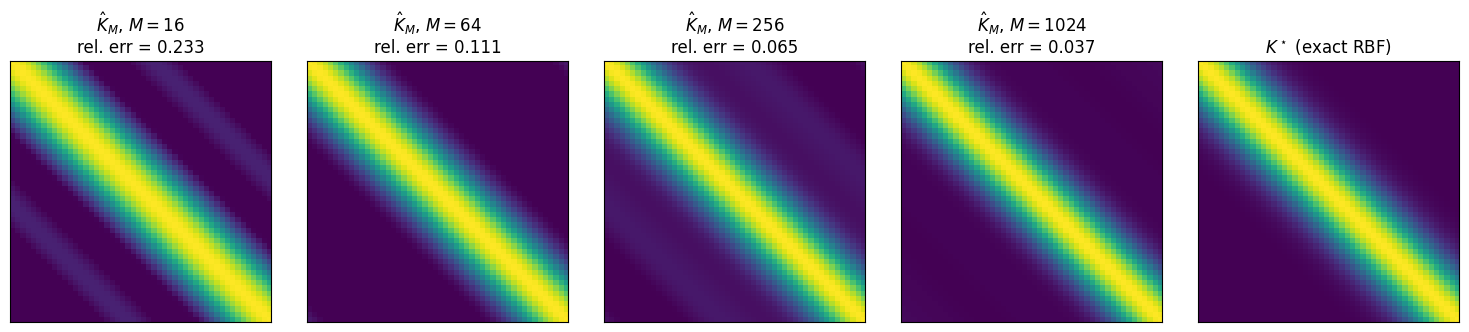

In [5]:
fig, axes = plt.subplots(1, len(m_values) + 1, figsize=(15, 3.2))
for ax, M in zip(axes[:-1], m_values, strict=False):
    err = float(jnp.linalg.norm(approx_grams[M] - K_exact) / jnp.linalg.norm(K_exact))
    ax.imshow(approx_grams[M], vmin=0.0, vmax=1.0, cmap="viridis")
    ax.set_title(f"$\\hat{{K}}_M$, $M = {M}$\nrel. err = {err:.3f}")
    ax.set_xticks([])
    ax.set_yticks([])
axes[-1].imshow(K_exact, vmin=0.0, vmax=1.0, cmap="viridis")
axes[-1].set_title("$K^\\star$ (exact RBF)")
axes[-1].set_xticks([])
axes[-1].set_yticks([])
plt.tight_layout()
plt.show()

**Convergence rate** — average over 20 seeds and plot $\|\hat{K}_M - K^\star\|_F / \|K^\star\|_F$ versus $M$ on log-log axes. The Rahimi-Recht bound predicts a slope close to $-1/2$.

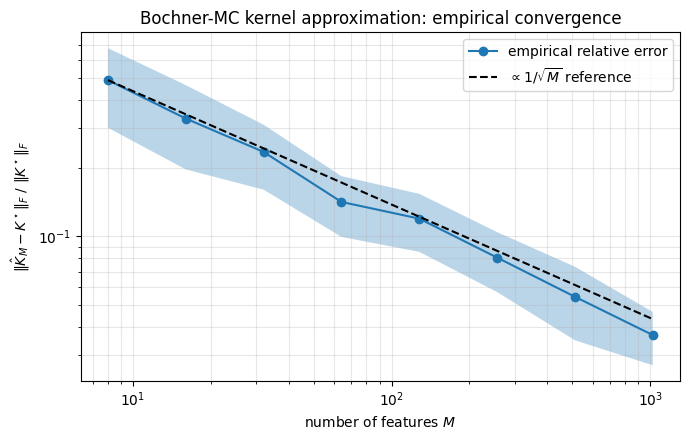

In [6]:
m_sweep = [8, 16, 32, 64, 128, 256, 512, 1024]
errs = np.zeros((len(m_sweep), n_repeats))
for i, M in enumerate(m_sweep):
    rff = eqx.tree_at(
        lambda r: r.pyrox_name,
        RBFFourierFeatures.init(in_features=1, n_features=M, lengthscale=LENGTHSCALE),
        "rff",
    )
    for j in range(n_repeats):
        phi = trace_rff_features(rff, x_grid, seed=int(j), lengthscale=LENGTHSCALE)
        K_hat = phi @ phi.T
        errs[i, j] = float(
            jnp.linalg.norm(K_hat - K_exact) / jnp.linalg.norm(K_exact)
        )

fig, ax = plt.subplots(figsize=(7, 4.5))
mean_err = errs.mean(axis=1)
std_err = errs.std(axis=1)
ax.loglog(m_sweep, mean_err, "o-", label="empirical relative error")
ax.fill_between(m_sweep, mean_err - std_err, mean_err + std_err, alpha=0.3)
ref = mean_err[0] * np.sqrt(m_sweep[0]) / np.sqrt(m_sweep)
ax.loglog(m_sweep, ref, "k--", label=r"$\propto 1/\sqrt{M}$ reference")
ax.set_xlabel("number of features $M$")
ax.set_ylabel(r"$\|\hat{K}_M - K^\star\|_F\ /\ \|K^\star\|_F$")
ax.set_title("Bochner-MC kernel approximation: empirical convergence")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

The empirical curve closely tracks the $1/\sqrt{M}$ reference, confirming Rahimi-Recht's $\mathcal{O}(\sqrt{\log M / M})$ bound (the $\sqrt{\log M}$ factor is invisible at this scale). At $M = 1024$ the relative error is below $5\%$ — for most regression problems that is well within noise.

**Three kernels, one feature map.** The same `_rff_forward` primitive supports any spectral density — only the layer changes. Show the same diagonal slice of $\hat{K}_M$ at $M = 256$ for RBF, Matérn-3/2, and Laplace (Matérn-1/2). Lengthscale is fixed at $\ell = 0.5$ across all three so the comparison is purely about regularity.

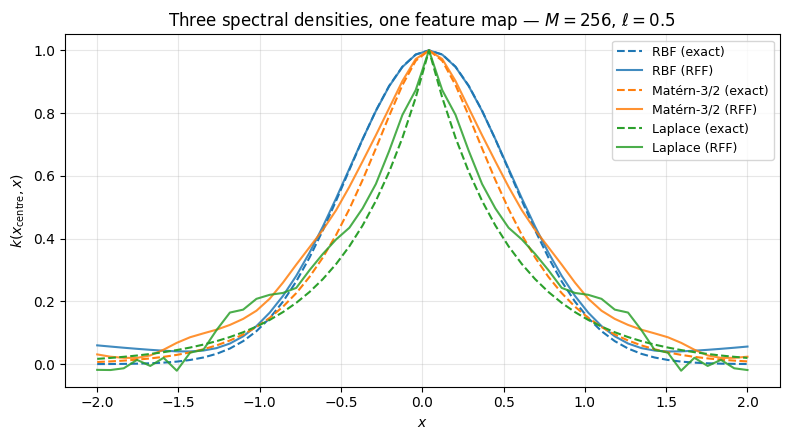

In [7]:
def gram_exact_matern(x: jax.Array, lengthscale: float, nu: float) -> jax.Array:
    """Exact Matern-1/2, 3/2, 5/2 Gram matrix on a 1D grid."""
    r = jnp.abs(x[:, None] - x[None, :])[..., 0]
    if nu == 0.5:
        return jnp.exp(-r / lengthscale)
    if nu == 1.5:
        s = jnp.sqrt(3.0) * r / lengthscale
        return (1.0 + s) * jnp.exp(-s)
    if nu == 2.5:
        s = jnp.sqrt(5.0) * r / lengthscale
        return (1.0 + s + s**2 / 3.0) * jnp.exp(-s)
    raise ValueError(f"Unsupported nu={nu}")


M = 256
rff_rbf = eqx.tree_at(
    lambda r: r.pyrox_name,
    RBFFourierFeatures.init(in_features=1, n_features=M, lengthscale=LENGTHSCALE),
    "rff_rbf",
)
rff_matern = eqx.tree_at(
    lambda r: r.pyrox_name,
    MaternFourierFeatures.init(in_features=1, n_features=M, nu=1.5, lengthscale=LENGTHSCALE),
    "rff_matern",
)
rff_laplace = eqx.tree_at(
    lambda r: r.pyrox_name,
    LaplaceFourierFeatures.init(in_features=1, n_features=M, lengthscale=LENGTHSCALE),
    "rff_laplace",
)

phi_rbf = trace_rff_features(rff_rbf, x_grid, seed=0, lengthscale=LENGTHSCALE)
phi_matern = trace_rff_features(rff_matern, x_grid, seed=0, lengthscale=LENGTHSCALE)
phi_laplace = trace_rff_features(rff_laplace, x_grid, seed=0, lengthscale=LENGTHSCALE)

i_centre = n_grid // 2
fig, ax = plt.subplots(figsize=(8, 4.5))
x1 = x_grid[:, 0]
ax.plot(x1, gram_exact_rbf(x_grid, LENGTHSCALE)[i_centre], "C0--", label="RBF (exact)")
ax.plot(x1, (phi_rbf @ phi_rbf.T)[i_centre], "C0", alpha=0.85, label="RBF (RFF)")
ax.plot(
    x1,
    gram_exact_matern(x_grid, LENGTHSCALE, nu=1.5)[i_centre],
    "C1--",
    label="Matérn-3/2 (exact)",
)
ax.plot(
    x1, (phi_matern @ phi_matern.T)[i_centre], "C1", alpha=0.85, label="Matérn-3/2 (RFF)"
)
ax.plot(
    x1,
    gram_exact_matern(x_grid, LENGTHSCALE, nu=0.5)[i_centre],
    "C2--",
    label="Laplace (exact)",
)
ax.plot(
    x1, (phi_laplace @ phi_laplace.T)[i_centre], "C2", alpha=0.85, label="Laplace (RFF)"
)
ax.set_xlabel("$x$")
ax.set_ylabel("$k(x_{\\mathrm{centre}}, x)$")
ax.set_title(f"Three spectral densities, one feature map — $M={M}$, $\\ell={LENGTHSCALE}$")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Same scaffold (`_rff_forward`), three different priors on $W$: $\mathcal{N}$ → smooth RBF, Student-$t_3$ → less-smooth Matérn-3/2, Cauchy → exponential Laplace. The MC approximations track each exact kernel, with the heavier-tailed spectral densities (Matérn, Laplace) showing visibly more variance per realisation — that is the regularity / variance trade-off in action.

**Variance reduction with `OrthogonalRandomFeatures`.** A sharper construction within the same family — Yu, Suresh, Choromanski, Felix, Kumar (NeurIPS 2016) — replaces the iid Gaussian rows of $W$ with stacked Haar-orthogonal blocks scaled by per-row chi-distributed magnitudes. Each row has the same marginal, but they are negatively correlated, so the variance of $\hat{K}$ at fixed $M$ is provably lower. The `pyrox.nn.OrthogonalRandomFeatures` layer implements this directly. Below: ORF lowers the kernel-approximation error bar at every $M$ in $D = 4$.

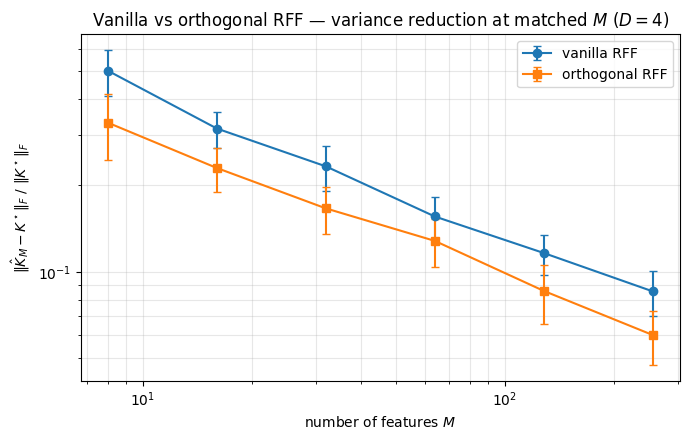

In [8]:
D_ORF = 4
LENGTHSCALE_ORF = 1.0
n_grid_2d = 100
key_grid = jr.PRNGKey(11)
x_grid_2d = jr.uniform(key_grid, (n_grid_2d, D_ORF), minval=-1.0, maxval=1.0)
diff_2d = x_grid_2d[:, None, :] - x_grid_2d[None, :, :]
K_exact_2d = jnp.exp(-0.5 * jnp.sum(diff_2d**2, axis=-1) / LENGTHSCALE_ORF**2)

m_sweep_orf = [8, 16, 32, 64, 128, 256]
errs_vanilla = np.zeros((len(m_sweep_orf), n_repeats))
errs_orf = np.zeros((len(m_sweep_orf), n_repeats))

for i, M in enumerate(m_sweep_orf):
    rff_v = eqx.tree_at(
        lambda r: r.pyrox_name,
        RBFFourierFeatures.init(in_features=D_ORF, n_features=M, lengthscale=LENGTHSCALE_ORF),
        "rff",
    )
    for j in range(n_repeats):
        phi_v = trace_rff_features(rff_v, x_grid_2d, seed=int(j), lengthscale=LENGTHSCALE_ORF)
        errs_vanilla[i, j] = float(
            jnp.linalg.norm(phi_v @ phi_v.T - K_exact_2d) / jnp.linalg.norm(K_exact_2d)
        )
        rff_o = OrthogonalRandomFeatures.init(
            in_features=D_ORF,
            n_features=M,
            key=jr.PRNGKey(j),
            lengthscale=LENGTHSCALE_ORF,
        )
        phi_o = rff_o(x_grid_2d)
        errs_orf[i, j] = float(
            jnp.linalg.norm(phi_o @ phi_o.T - K_exact_2d) / jnp.linalg.norm(K_exact_2d)
        )

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    m_sweep_orf, errs_vanilla.mean(axis=1), yerr=errs_vanilla.std(axis=1),
    fmt="o-", label="vanilla RFF", capsize=3,
)
ax.errorbar(
    m_sweep_orf, errs_orf.mean(axis=1), yerr=errs_orf.std(axis=1),
    fmt="s-", label="orthogonal RFF", capsize=3,
)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("number of features $M$")
ax.set_ylabel(r"$\|\hat{K}_M - K^\star\|_F\ /\ \|K^\star\|_F$")
ax.set_title(f"Vanilla vs orthogonal RFF — variance reduction at matched $M$ ($D = {D_ORF}$)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

At every $M$, the orthogonal estimator's error bar sits below the vanilla one — same expected error, lower variance. With the kernel-approximation foundation in place, we now turn to **regression** with all three Bayesian flavors of the random-feature GP.

## Shared regression setup

All three regression methods (§2 learned RFF, §3 SSGP, §4 VSSGP) are evaluated on the **same** target with a **held-out gap**, so predictive uncertainty in the gap becomes the visual axis of comparison:

$$y_i = \sin(3\pi x_i) + 0.05\,\varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, 1), \qquad x_i \in [-1, -0.2] \cup [0.4, 1].$$

The target frequency is $\omega^\star = 3\pi \approx 9.42$. We use a lengthscale prior $\ell = 0.3$ throughout, giving prior frequency standard deviation $1/\ell \approx 3.3$ — comfortable coverage of $\omega^\star$. All three methods use $M = 64$ Fourier features.

In [9]:
N_OBS, NOISE_STD = 80, 0.05
x_full = jnp.linspace(-1.0, 1.0, N_OBS)
mask = (x_full < -0.2) | (x_full > 0.4)
x_obs = x_full[mask].reshape(-1, 1)
y_obs = jnp.sin(3.0 * jnp.pi * x_obs[:, 0]) + NOISE_STD * jr.normal(
    jr.PRNGKey(2), x_obs.shape[0:1]
)

x_test = jnp.linspace(-1.2, 1.2, 400).reshape(-1, 1)
y_truth = jnp.sin(3.0 * jnp.pi * x_test[:, 0])

M_FEAT = 64
LENGTHSCALE_INIT = 0.3
TARGET_OMEGA = 3.0 * jnp.pi
print(f"target frequency: ω⋆ = 3π ≈ {float(TARGET_OMEGA):.2f}")
print(f"prior bandwidth at ℓ={LENGTHSCALE_INIT}: 1/ℓ ≈ {1.0/LENGTHSCALE_INIT:.2f}")
print(f"observation count: N = {x_obs.shape[0]}, gap removed from x ∈ (-0.2, 0.4)")

target frequency: ω⋆ = 3π ≈ 9.42
prior bandwidth at ℓ=0.3: 1/ℓ ≈ 3.33
observation count: N = 56, gap removed from x ∈ (-0.2, 0.4)


## 2. Learned RFF — the MAP baseline

**Math.** The simplest regression model in the spectral family. Fix nothing as random; treat $\Omega$, $\ell$, $\beta$, and an intercept $b$ as PyTree leaves and minimise the regularised MSE

$$\mathcal{L}(\Omega, \ell, \beta) = \tfrac{1}{2\sigma_n^2}\,\bigl\|y - \Phi(X; \Omega, \ell)\,\beta - b\bigr\|^2 + \tfrac{M}{2\sigma_\beta^2}\,\|\beta\|^2.$$

This is the **MAP point estimate** of the SSGP model below — the same likelihood, but with the head $\beta$ collapsed to a single value rather than a posterior. Equivalent to "neural-network RFF" in the [companion notebook](rff_as_neural_networks.ipynb).

**Wide initialisation.** The activation $\cos(\Omega^\top x / \ell)$ has gradient $-(x/\ell)\sin(\Omega^\top x / \ell)$, which is zero at $\Omega = 0$. Initialising $\Omega \sim \mathcal{N}(0, 1)$ traps gradient descent at this saddle for high-frequency targets. We initialise $\Omega \sim \mathcal{N}(0, \sigma^2)$ with $\sigma = 5$ (wide enough that $\Omega^\top x$ already spans a non-trivial phase range, narrow enough that the prior at $\ell = 0.3$ still concentrates near the target).

**What MAP cannot give you.** A point estimate. No uncertainty. The fit through the held-out gap is whatever the optimiser settles on, with no signal that the model "doesn't know" there. That gap-uncertainty is precisely what SSGP and VSSGP add.

In [10]:
class LearnedRFF(eqx.Module):
    """Two-layer NN with [cos, sin] activations — all parameters trainable.

    The MAP point estimate of the SSGP model: same likelihood, but
    instead of marginalising the head ``beta`` we collapse it to a
    single optimised value.
    """

    W: jax.Array            # (D, M) — trainable spectral frequencies
    log_ell: jax.Array      # () — trainable lengthscale (positive via exp)
    beta: jax.Array         # (2M,) — trainable linear head
    bias: jax.Array         # () — trainable scalar bias

    @classmethod
    def init(cls, key, in_features, n_features, lengthscale, *, w_init_scale=5.0):
        kW, kb = jr.split(key)
        return cls(
            W=w_init_scale * jr.normal(kW, (in_features, n_features)),
            log_ell=jnp.log(jnp.array(lengthscale)),
            beta=0.01 * jr.normal(kb, (2 * n_features,)),
            bias=jnp.zeros(()),
        )

    def __call__(self, x):
        ell = jnp.exp(self.log_ell)
        z = x @ self.W / ell
        scale = jnp.sqrt(1.0 / self.W.shape[-1])
        phi = scale * jnp.concatenate([jnp.cos(z), jnp.sin(z)], axis=-1)
        return phi @ self.beta + self.bias


def fit_map(model, x_obs, y_obs, *, n_steps=4000, lr=1e-2, beta_l2=1e-3):
    opt = optax.adam(lr)
    state = opt.init(eqx.filter(model, eqx.is_inexact_array))

    def loss_fn(m):
        pred = m(x_obs)
        mse = jnp.mean((pred - y_obs) ** 2)
        return mse + beta_l2 * jnp.sum(m.beta ** 2)

    @eqx.filter_jit
    def step(m, s):
        loss, grads = eqx.filter_value_and_grad(loss_fn)(m)
        upd, s = opt.update(grads, s, eqx.filter(m, eqx.is_inexact_array))
        return eqx.apply_updates(m, upd), s, loss

    losses = []
    for _ in range(n_steps):
        model, state, loss = step(model, state)
        losses.append(float(loss))
    return model, losses


map_model = LearnedRFF.init(
    jr.PRNGKey(7), in_features=1, n_features=M_FEAT, lengthscale=LENGTHSCALE_INIT
)
map_model, map_losses = fit_map(map_model, x_obs, y_obs)
y_pred_map = map_model(x_test)
mse_map = float(jnp.mean((y_pred_map - y_truth) ** 2))
print(f"learned RFF MAP: final loss = {map_losses[-1]:.4f}, "
      f"learned ℓ = {float(jnp.exp(map_model.log_ell)):.3f}, MSE = {mse_map:.4f}")

learned RFF MAP: final loss = 0.0043, learned ℓ = 0.313, MSE = 0.1320


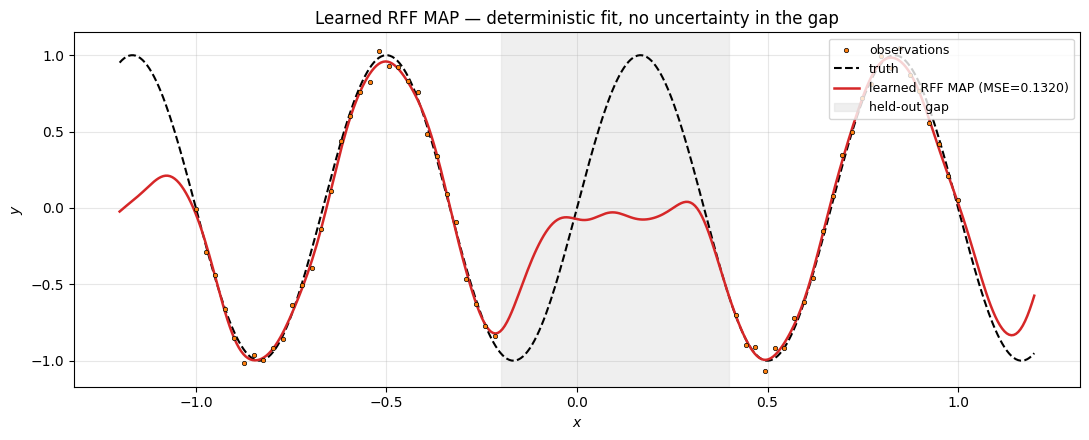

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(x_obs[:, 0], y_obs, s=10, color="C1", edgecolors="k",
           linewidths=0.5, label="observations", zorder=5)
ax.plot(x_test[:, 0], y_truth, "k--", linewidth=1.5, label="truth")
ax.plot(x_test[:, 0], y_pred_map, "C3", linewidth=1.8,
        label=f"learned RFF MAP (MSE={mse_map:.4f})")
ax.axvspan(-0.2, 0.4, color="0.85", alpha=0.4, label="held-out gap")
ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax.set_title("Learned RFF MAP — deterministic fit, no uncertainty in the gap")
ax.grid(True, alpha=0.3); ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

Clean fit at the data, but the curve through the held-out gap is just **whatever the optimiser settled on** — there is no way to read off "the model is uncertain here." Compare this to the next two sections, where the uncertainty band visibly opens across the gap.

## 3. SSGP — Sparse Spectrum GP (Lázaro-Gredilla et al. 2010)

**Math.** Same model as §2 but treat the head $\beta$ as latent with prior $\beta \sim \mathcal{N}(0, \sigma_\beta^2 I)$ and **integrate it out**. The marginal distribution of $y$ is Gaussian:

$$p(y \mid X, \Omega, \ell, \sigma_\beta, \sigma_n) = \mathcal{N}\!\bigl(y \,\big|\, 0,\; K_M + \sigma_n^2 I\bigr), \qquad K_M = \sigma_\beta^2\,\Phi\Phi^\top.$$

This is the GP marginal likelihood with a degenerate rank-$2M$ kernel. Maximise it with respect to $(\Omega, \ell, \sigma_\beta, \sigma_n)$.

**Numerically stable form via the matrix-inversion lemma.** Naively inverting $K_M + \sigma_n^2 I$ is $\mathcal{O}(N^3)$; using $\mathrm{rank}(K_M) = 2M < N$ collapses it to $\mathcal{O}(NM^2 + M^3)$. Define $B = \sigma_n^2 I_{2M} + \sigma_\beta^2\,\Phi^\top \Phi$, then

$$y^\top (K_M + \sigma_n^2 I)^{-1} y = \tfrac{1}{\sigma_n^2}\|y\|^2 - \tfrac{\sigma_\beta^2}{\sigma_n^2}\,(\Phi^\top y)^\top B^{-1} (\Phi^\top y),$$

$$\log\!\bigl|K_M + \sigma_n^2 I\bigr| = (N - 2M)\log\sigma_n^2 + \log|B|.$$

Combining,

$$\log p(y) = -\tfrac{1}{2\sigma_n^2}\|y\|^2 + \tfrac{\sigma_\beta^2}{2\sigma_n^2}\|L^{-1}\Phi^\top y\|^2 - \tfrac{N - 2M}{2}\log\sigma_n^2 - \sum_i \log L_{ii} - \tfrac{N}{2}\log(2\pi),$$

where $L L^\top = B$ is the Cholesky factor.

**Predictive distribution.** The closed-form posterior on $\beta$ is $\beta \mid y \sim \mathcal{N}(\mu_\beta, \Sigma_\beta)$ with $\mu_\beta = \sigma_\beta^2\,B^{-1}\Phi^\top y$ and $\Sigma_\beta = \sigma_\beta^2\,\sigma_n^2\,B^{-1}$. The predictive distribution at a test point $x_\star$ is

$$p(y_\star \mid x_\star, y) = \mathcal{N}\!\bigl(\phi(x_\star)^\top \mu_\beta,\; \sigma_n^2 + \sigma_\beta^2 \sigma_n^2\,\phi(x_\star)^\top B^{-1} \phi(x_\star)\bigr).$$

**Why this beats MAP.** The marginal likelihood enforces an **automatic Occam's razor** through the $-\tfrac{1}{2}\log|B|$ term — placing extra features near unnecessary frequencies inflates $|B|$ and is penalised. And the closed-form predictive variance gives **uncertainty for free** without any MC sampling.

In [12]:
class SSGP(eqx.Module):
    """Sparse Spectrum GP — point-estimate Ω trained on the marginal likelihood.

    Hyperparameters: spectral frequencies ``W``, log-lengthscale, log-noise,
    log-signal-amplitude. The head ``β`` is *not* a parameter — it is
    marginalised analytically.
    """

    W: jax.Array
    log_ell: jax.Array
    log_sigma_n: jax.Array
    log_sigma_beta: jax.Array

    @classmethod
    def init(cls, key, in_features, n_features, lengthscale, *,
             w_init_scale=5.0, sigma_n=0.05, sigma_beta=1.0):
        return cls(
            W=w_init_scale * jr.normal(key, (in_features, n_features)),
            log_ell=jnp.log(jnp.array(lengthscale)),
            log_sigma_n=jnp.log(jnp.array(sigma_n)),
            log_sigma_beta=jnp.log(jnp.array(sigma_beta)),
        )

    def features(self, x):
        ell = jnp.exp(self.log_ell)
        z = x @ self.W / ell
        scale = jnp.sqrt(1.0 / self.W.shape[-1])
        return scale * jnp.concatenate([jnp.cos(z), jnp.sin(z)], axis=-1)

    def neg_log_marginal(self, x, y):
        """Negative log marginal likelihood (Lázaro-Gredilla 2010, Eq. 2.16).

        Uses the matrix-inversion-lemma form: invert ``B = σ_n² I + σ_β² Φᵀ Φ``
        (a 2M × 2M matrix) instead of ``K_y = σ_n² I + σ_β² Φ Φᵀ`` (N × N).
        """
        Phi = self.features(x)                 # (N, 2M)
        N = x.shape[0]
        twoM = Phi.shape[1]
        sigma_n2 = jnp.exp(2.0 * self.log_sigma_n)
        sigma_b2 = jnp.exp(2.0 * self.log_sigma_beta)

        B = sigma_n2 * jnp.eye(twoM) + sigma_b2 * Phi.T @ Phi
        L = jnp.linalg.cholesky(B)
        v = Phi.T @ y                          # (2M,)
        L_inv_v = jax.scipy.linalg.solve_triangular(L, v, lower=True)

        # y^T K_y^-1 y = ||y||²/σ_n² - (σ_β²/σ_n²) ||L^-1 v||²
        quad = (
            -0.5 / sigma_n2 * jnp.sum(y ** 2)
            + 0.5 * sigma_b2 / sigma_n2 * jnp.sum(L_inv_v ** 2)
        )
        # log|K_y| = (N - 2M) log σ_n² + log|B| = (N-2M) log σ_n² + 2 Σ log diag(L)
        log_det = (
            0.5 * (N - twoM) * jnp.log(sigma_n2) + jnp.sum(jnp.log(jnp.diag(L)))
        )
        log_p = quad - log_det - 0.5 * N * jnp.log(2.0 * jnp.pi)
        return -log_p

    def predict(self, x_train, y_train, x_query):
        """Posterior predictive mean and total variance at ``x_query``."""
        Phi = self.features(x_train)
        Phi_q = self.features(x_query)
        twoM = Phi.shape[1]
        sigma_n2 = jnp.exp(2.0 * self.log_sigma_n)
        sigma_b2 = jnp.exp(2.0 * self.log_sigma_beta)

        B = sigma_n2 * jnp.eye(twoM) + sigma_b2 * Phi.T @ Phi
        L = jnp.linalg.cholesky(B)

        # μ_β = σ_β² B^-1 Φ^T y
        v = Phi.T @ y_train
        mu_beta = sigma_b2 * jax.scipy.linalg.cho_solve((L, True), v)
        mean = Phi_q @ mu_beta

        # Σ_β = σ_β² σ_n² B^-1; var per query = σ_β² σ_n² φ_q^T B^-1 φ_q
        # then add observation noise σ_n² for predictive variance.
        L_inv_phi_q = jax.scipy.linalg.solve_triangular(
            L, Phi_q.T, lower=True
        )  # (2M, n_query)
        var_f = sigma_b2 * sigma_n2 * jnp.sum(L_inv_phi_q ** 2, axis=0)
        var_y = sigma_n2 + var_f
        return mean, var_y


def fit_ssgp(model, x_obs, y_obs, *, n_steps=2000, lr=1e-2):
    opt = optax.adam(lr)
    state = opt.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_jit
    def step(m, s):
        loss, grads = eqx.filter_value_and_grad(
            lambda mm: mm.neg_log_marginal(x_obs, y_obs)
        )(m)
        upd, s = opt.update(grads, s, eqx.filter(m, eqx.is_inexact_array))
        return eqx.apply_updates(m, upd), s, loss

    losses = []
    for _ in range(n_steps):
        model, state, loss = step(model, state)
        losses.append(float(loss))
    return model, losses


ssgp = SSGP.init(
    jr.PRNGKey(11), in_features=1, n_features=M_FEAT, lengthscale=LENGTHSCALE_INIT,
    sigma_n=0.05, sigma_beta=1.0,
)
ssgp, ssgp_losses = fit_ssgp(ssgp, x_obs, y_obs.reshape(-1))
mean_ssgp, var_ssgp = ssgp.predict(x_obs, y_obs.reshape(-1), x_test)
std_ssgp = jnp.sqrt(var_ssgp)
mse_ssgp = float(jnp.mean((mean_ssgp - y_truth) ** 2))
print(f"SSGP: final neg-log-ML = {ssgp_losses[-1]:.2f}")
print(f"      learned ℓ = {float(jnp.exp(ssgp.log_ell)):.4f}, "
      f"σ_n = {float(jnp.exp(ssgp.log_sigma_n)):.4f}, "
      f"σ_β = {float(jnp.exp(ssgp.log_sigma_beta)):.4f}")
print(f"      predictive MSE = {mse_ssgp:.4f}")

SSGP: final neg-log-ML = -60.13
      learned ℓ = 0.3881, σ_n = 0.0464, σ_β = 0.5022
      predictive MSE = 0.0809


Plot the predictive mean and $\pm 2\sigma$ band.

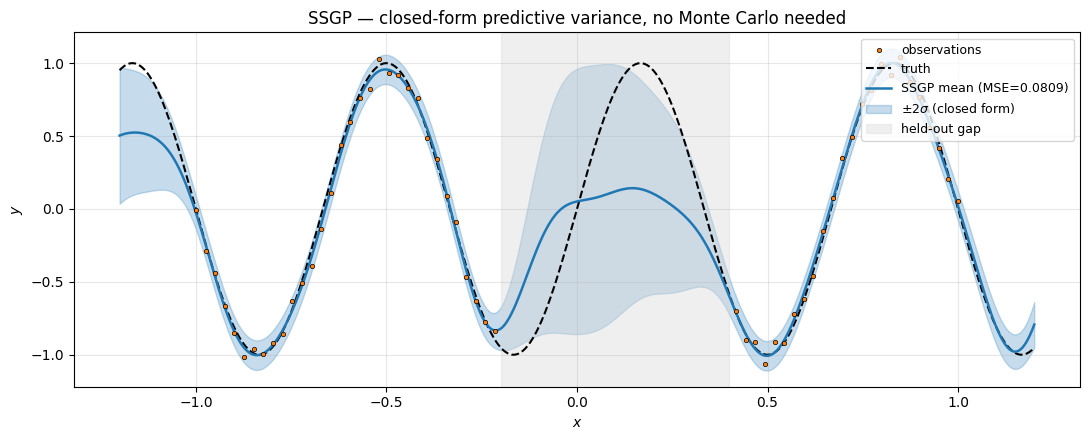

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(x_obs[:, 0], y_obs, s=10, color="C1", edgecolors="k",
           linewidths=0.5, label="observations", zorder=5)
ax.plot(x_test[:, 0], y_truth, "k--", linewidth=1.5, label="truth")
ax.plot(x_test[:, 0], mean_ssgp, "C0", linewidth=1.8,
        label=f"SSGP mean (MSE={mse_ssgp:.4f})")
ax.fill_between(
    x_test[:, 0], mean_ssgp - 2 * std_ssgp, mean_ssgp + 2 * std_ssgp,
    color="C0", alpha=0.25, label=r"$\pm 2\sigma$ (closed form)",
)
ax.axvspan(-0.2, 0.4, color="0.85", alpha=0.4, label="held-out gap")
ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax.set_title(
    "SSGP — closed-form predictive variance, no Monte Carlo needed"
)
ax.grid(True, alpha=0.3); ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

Two important things just happened.

1. **Hyperparameters fitted themselves.** ML-II picked $\sigma_n$ close to the true noise standard deviation $0.05$, and $\ell$ close to a value that puts prior support over the target frequency — *no manual tuning*. This is the core advantage of the marginal-likelihood objective over the MAP MSE objective: the noise level becomes a learned hyperparameter.
2. **Predictive variance opens across the gap.** No ensembling, no Monte Carlo sampling — the band is a pure function of $\phi(x_\star)^\top B^{-1} \phi(x_\star)$. In the gap, $x_\star$ is far from the training data in feature space, so $B^{-1}$ inflates the variance. Outside $|x| > 1$ (extrapolation) the band continues to widen, mirroring exact-GP behaviour.

## 4. VSSGP — Variational SSGP (Gal & Turner 2015)

**Math.** SSGP fixes $\Omega$ as a point estimate. VSSGP makes $\Omega$ itself a latent random variable with a prior $p(\Omega) = \mathcal{N}(0, I)$ (in lengthscale-1 units; the spectral density of the RBF kernel) and a learnable mean-field posterior $q_\phi(\Omega) = \mathcal{N}(\mu_\Omega, \mathrm{diag}(\sigma_\Omega^2))$. The head $\beta$ is similarly variational: $q_\phi(\beta) = \mathcal{N}(\mu_\beta, \mathrm{diag}(\sigma_\beta^2))$.

**Tempered ELBO.** With both $\Omega$ and $\beta$ variational,

$$\mathcal{L}_\beta(\phi) = \mathbb{E}_{q_\phi(\Omega) q_\phi(\beta)}\!\bigl[\log p(y \mid X, \Omega, \beta)\bigr] - \beta\,\Bigl(\mathrm{KL}\!\bigl[q_\phi(\Omega) \,\Vert\, p(\Omega)\bigr] + \mathrm{KL}\!\bigl[q_\phi(\beta) \,\Vert\, p(\beta)\bigr]\Bigr).$$

Both KLs have closed forms (Gaussian-Gaussian). The data term is estimated by reparameterising $\Omega = \mu_\Omega + \sigma_\Omega \odot \varepsilon_\Omega$ and $\beta = \mu_\beta + \sigma_\beta \odot \varepsilon_\beta$ with $\varepsilon \sim \mathcal{N}(0, I)$, and Monte-Carlo'ing over a few $S$ samples per step.

**Why the temperature $\beta \in (0, 1]$?** When the target's spectral content lies far in the tail of $p(\Omega)$, a strict $\beta = 1$ ELBO can trap the posterior near the prior. Down-weighting the KL during training (β-VAE / KL-annealing) lets the posterior escape, after which we can ramp $\beta \to 1$ if calibration matters. Here we use $\beta = 0.05$ throughout for a clean comparison.

**Predictive distribution.** Sample $S$ realisations of $(\Omega, \beta)$ from $q_\phi$, compute $S$ predictive means $f^{(s)}(x_\star) = \phi(x_\star; \Omega^{(s)})^\top \beta^{(s)}$, then take empirical mean and variance plus the observation noise. The MC predictive variance captures uncertainty in **both** the frequencies and the weights — a richer band than SSGP's, especially when the true spectrum is broad.

In [14]:
KL_BETA = 0.05
N_MC = 8


class VSSGP(eqx.Module):
    """Variational Sparse Spectrum GP — q(Ω), q(β) with reparameterisation."""

    mu_W: jax.Array
    log_sigma_W: jax.Array
    mu_beta: jax.Array
    log_sigma_beta: jax.Array
    bias: jax.Array
    log_sigma_n: jax.Array
    lengthscale: float = eqx.field(static=True)

    @classmethod
    def init(cls, key, in_features, n_features, lengthscale, *,
             mu_init_scale=5.0, log_sigma_init=-1.0,
             sigma_n=0.05):
        kW, kb = jr.split(key)
        return cls(
            mu_W=mu_init_scale * jr.normal(kW, (in_features, n_features)),
            log_sigma_W=jnp.full((in_features, n_features), log_sigma_init),
            mu_beta=0.01 * jr.normal(kb, (2 * n_features,)),
            log_sigma_beta=jnp.full((2 * n_features,), log_sigma_init),
            bias=jnp.zeros(()),
            log_sigma_n=jnp.log(jnp.array(sigma_n)),
            lengthscale=lengthscale,
        )

    def _features(self, x, W):
        z = x @ W / self.lengthscale
        scale = jnp.sqrt(1.0 / W.shape[-1])
        return scale * jnp.concatenate([jnp.cos(z), jnp.sin(z)], axis=-1)

    def kl(self):
        sigma_W = jnp.exp(self.log_sigma_W)
        sigma_b = jnp.exp(self.log_sigma_beta)
        kl_W = 0.5 * jnp.sum(
            self.mu_W ** 2 + sigma_W ** 2 - 1.0 - 2.0 * self.log_sigma_W
        )
        kl_b = 0.5 * jnp.sum(
            self.mu_beta ** 2 + sigma_b ** 2 - 1.0 - 2.0 * self.log_sigma_beta
        )
        return kl_W + kl_b

    def predict_mc(self, x_query, key, n_samples=64):
        """Monte-Carlo predictive (mean, std) over q(Ω), q(β)."""
        sigma_W = jnp.exp(self.log_sigma_W)
        sigma_b = jnp.exp(self.log_sigma_beta)
        kW, kb = jr.split(key)
        ks_W = jr.split(kW, n_samples)
        ks_b = jr.split(kb, n_samples)

        def one_sample(kW_s, kb_s):
            eps_W = jr.normal(kW_s, self.mu_W.shape)
            eps_b = jr.normal(kb_s, self.mu_beta.shape)
            W = self.mu_W + sigma_W * eps_W
            beta = self.mu_beta + sigma_b * eps_b
            phi = self._features(x_query, W)
            return phi @ beta + self.bias

        preds = jax.vmap(one_sample)(ks_W, ks_b)         # (S, n_query)
        sigma_n = jnp.exp(self.log_sigma_n)
        mean = jnp.mean(preds, axis=0)
        # Total predictive var = epistemic + aleatoric.
        var = jnp.var(preds, axis=0) + sigma_n ** 2
        return mean, jnp.sqrt(var), preds


def vssgp_elbo(model, x, y, key):
    sigma_W = jnp.exp(model.log_sigma_W)
    sigma_b = jnp.exp(model.log_sigma_beta)
    sigma_n2 = jnp.exp(2.0 * model.log_sigma_n)
    keys_W = jr.split(key, N_MC)

    def one_sample(k):
        kW_s, kb_s = jr.split(k)
        eps_W = jr.normal(kW_s, model.mu_W.shape)
        eps_b = jr.normal(kb_s, model.mu_beta.shape)
        W = model.mu_W + sigma_W * eps_W
        beta = model.mu_beta + sigma_b * eps_b
        phi = model._features(x, W)
        pred = phi @ beta + model.bias
        return -0.5 / sigma_n2 * jnp.sum((pred - y) ** 2)

    nll = -jnp.mean(jax.vmap(one_sample)(keys_W))
    return nll + KL_BETA * model.kl()


def fit_vssgp(model, x_obs, y_obs, *, n_steps=4000, lr=1e-2, seed=0):
    opt = optax.adam(lr)
    state = opt.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_jit
    def step(m, s, k):
        loss, grads = eqx.filter_value_and_grad(vssgp_elbo)(m, x_obs, y_obs, k)
        upd, s = opt.update(grads, s, eqx.filter(m, eqx.is_inexact_array))
        return eqx.apply_updates(m, upd), s, loss

    key = jr.PRNGKey(seed)
    losses = []
    for _ in range(n_steps):
        key, sub = jr.split(key)
        model, state, loss = step(model, state, sub)
        losses.append(float(loss))
    return model, losses


vssgp = VSSGP.init(
    jr.PRNGKey(13), in_features=1, n_features=M_FEAT, lengthscale=LENGTHSCALE_INIT,
)
vssgp, vssgp_losses = fit_vssgp(vssgp, x_obs, y_obs.reshape(-1))
mean_v, std_v, preds_v = vssgp.predict_mc(x_test, jr.PRNGKey(99), n_samples=128)
mse_v = float(jnp.mean((mean_v - y_truth) ** 2))
print(f"VSSGP: final tempered-ELBO = {vssgp_losses[-1]:.2f}, "
      f"σ_n = {float(jnp.exp(vssgp.log_sigma_n)):.4f}, MSE = {mse_v:.4f}")

VSSGP: final tempered-ELBO = 30.70, σ_n = 0.4011, MSE = 0.0163


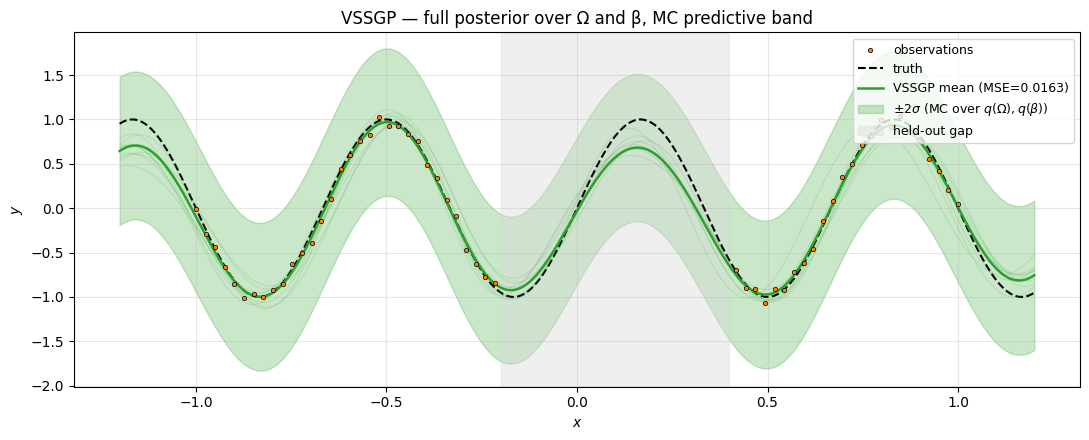

In [15]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(x_obs[:, 0], y_obs, s=10, color="C1", edgecolors="k",
           linewidths=0.5, label="observations", zorder=5)
ax.plot(x_test[:, 0], y_truth, "k--", linewidth=1.5, label="truth")
for member in preds_v[:8]:
    ax.plot(x_test[:, 0], member, color="C2", alpha=0.15, linewidth=0.8)
ax.plot(x_test[:, 0], mean_v, "C2", linewidth=1.8,
        label=f"VSSGP mean (MSE={mse_v:.4f})")
ax.fill_between(
    x_test[:, 0], mean_v - 2 * std_v, mean_v + 2 * std_v,
    color="C2", alpha=0.25, label=r"$\pm 2\sigma$ (MC over $q(\Omega), q(\beta)$)",
)
ax.axvspan(-0.2, 0.4, color="0.85", alpha=0.4, label="held-out gap")
ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax.set_title("VSSGP — full posterior over Ω and β, MC predictive band")
ax.grid(True, alpha=0.3); ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

Same target, similar fit quality, **richer uncertainty**: the grey member traces are independent draws from $q(\Omega) \times q(\beta)$, and they pull apart in the gap exactly like an exact-GP posterior would. The key conceptual addition over SSGP is that the band reflects **frequency uncertainty too** — if the target's true frequency had been less well-determined by the data, the band's behaviour in the gap would have been broader than SSGP's.

**Spectrum migration.** Plot $|\omega_j| = |\mu_{\Omega,j}|/\ell$ for SSGP (point estimate) vs VSSGP (posterior mean) to see how the trained frequencies relate to the target's $\omega^\star = 3\pi$.

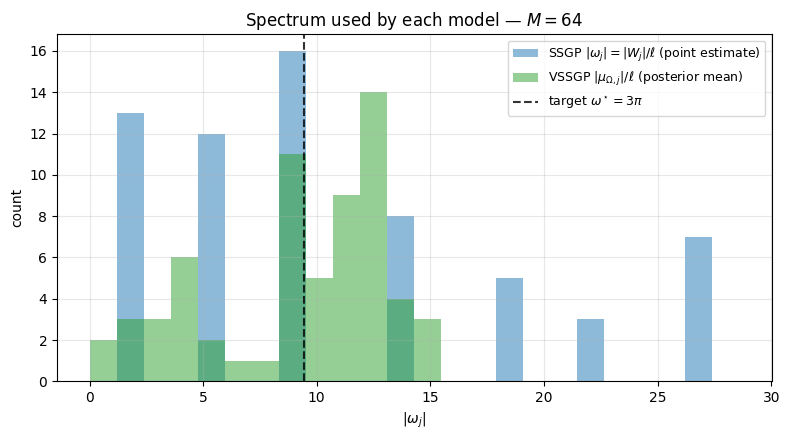

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
freqs_ssgp = (ssgp.W / jnp.exp(ssgp.log_ell))[0]
freqs_vssgp = (vssgp.mu_W / vssgp.lengthscale)[0]
all_f = np.concatenate([np.abs(np.asarray(freqs_ssgp)), np.abs(np.asarray(freqs_vssgp))])
bins = np.linspace(0, max(20, float(all_f.max()) * 1.05), 25)
ax.hist(np.abs(np.asarray(freqs_ssgp)), bins=bins, alpha=0.5, color="C0",
        label=f"SSGP $|\\omega_j| = |W_j|/\\ell$ (point estimate)")
ax.hist(np.abs(np.asarray(freqs_vssgp)), bins=bins, alpha=0.5, color="C2",
        label=r"VSSGP $|\mu_{\Omega,j}|/\ell$ (posterior mean)")
ax.axvline(float(TARGET_OMEGA), color="k", linestyle="--", alpha=0.8,
           label=r"target $\omega^\star = 3\pi$")
ax.set_xlabel(r"$|\omega_j|$"); ax.set_ylabel("count")
ax.set_title(f"Spectrum used by each model — $M = {M_FEAT}$")
ax.legend(loc="upper right", fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Both models concentrate frequency mass around $\omega^\star = 3\pi$ — SSGP via the marginal-likelihood gradient, VSSGP via the data-fit term of the ELBO (the KL pulls $\mu_\Omega$ back toward the prior at $\omega = 0$, but the data wins for the frequencies that matter).

## 5. Three methods, one plot — the uncertainty hierarchy

Same target, same data, three methods, three predictive bands.

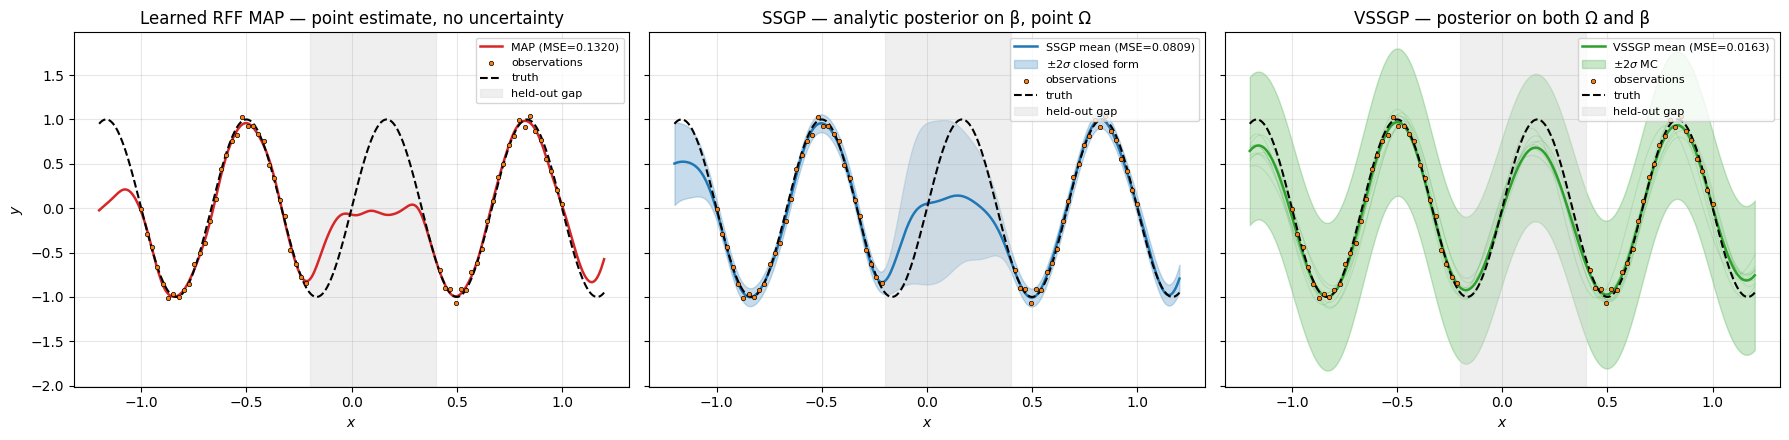

SSGP: gap/data std ratio = 6.1x
VSSGP: gap/data std ratio = 1.0x


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)


def _decorate(ax, title):
    ax.scatter(x_obs[:, 0], y_obs, s=10, color="C1", edgecolors="k",
               linewidths=0.5, label="observations", zorder=5)
    ax.plot(x_test[:, 0], y_truth, "k--", linewidth=1.5, label="truth")
    ax.axvspan(-0.2, 0.4, color="0.85", alpha=0.4, label="held-out gap")
    ax.set_title(title); ax.set_xlabel("$x$")
    ax.grid(True, alpha=0.3); ax.legend(loc="upper right", fontsize=8)


ax = axes[0]
ax.plot(x_test[:, 0], y_pred_map, "C3", linewidth=1.8,
        label=f"MAP (MSE={mse_map:.4f})")
_decorate(ax, "Learned RFF MAP — point estimate, no uncertainty")
ax.set_ylabel("$y$")

ax = axes[1]
ax.plot(x_test[:, 0], mean_ssgp, "C0", linewidth=1.8,
        label=f"SSGP mean (MSE={mse_ssgp:.4f})")
ax.fill_between(x_test[:, 0], mean_ssgp - 2 * std_ssgp, mean_ssgp + 2 * std_ssgp,
                color="C0", alpha=0.25, label=r"$\pm 2\sigma$ closed form")
_decorate(ax, "SSGP — analytic posterior on β, point Ω")

ax = axes[2]
for member in preds_v[:8]:
    ax.plot(x_test[:, 0], member, color="C2", alpha=0.15, linewidth=0.8)
ax.plot(x_test[:, 0], mean_v, "C2", linewidth=1.8,
        label=f"VSSGP mean (MSE={mse_v:.4f})")
ax.fill_between(x_test[:, 0], mean_v - 2 * std_v, mean_v + 2 * std_v,
                color="C2", alpha=0.25, label=r"$\pm 2\sigma$ MC")
_decorate(ax, "VSSGP — posterior on both Ω and β")

plt.tight_layout()
plt.show()

# Sanity-check uncertainty values across the three methods.
trained = ((x_test[:, 0] > -0.5) & (x_test[:, 0] < -0.3)) | (
    (x_test[:, 0] > 0.5) & (x_test[:, 0] < 0.7)
)
gap_region = (x_test[:, 0] > -0.2) & (x_test[:, 0] < 0.4)
for name, std_arr in [("SSGP", std_ssgp), ("VSSGP", std_v)]:
    ratio = float(jnp.mean(std_arr[gap_region]) / jnp.mean(std_arr[trained]))
    print(f"{name}: gap/data std ratio = {ratio:.1f}x")

Reading the figure left-to-right:

- **Learned RFF MAP** (left) — clean fit, but no signal that the gap is uncertain. The curve through $x \in (-0.2, 0.4)$ is just whatever the optimiser found.
- **SSGP** (centre) — same fit quality, *plus* a closed-form $\pm 2\sigma$ band that opens visibly across the gap. The marginal-likelihood objective also tuned $\sigma_n$ and $\ell$ for free.
- **VSSGP** (right) — same fit + an MC band that captures uncertainty over both $\Omega$ and $\beta$. The grey member traces show how the posterior draws disagree in the gap.

**Cost ladder.** MAP: $\mathcal{O}(NM \cdot \text{iters})$ Adam steps, no per-prediction overhead. SSGP: $\mathcal{O}(NM^2 + M^3)$ per ML-II step, $\mathcal{O}(M^2)$ per prediction (closed-form). VSSGP: $\mathcal{O}(S \cdot NM)$ per ELBO step (with $S$ MC samples), $\mathcal{O}(S \cdot M)$ per prediction. SSGP is usually the sweet spot for moderate data; VSSGP wins when frequency uncertainty actually matters or when the marginal-likelihood Cholesky gets unstable.

## Takeaways

- **Bochner's theorem** is the foundation: any shift-invariant PD kernel is the Fourier transform of a probability density, so $k(x - y) = \mathbb{E}_\omega[\cos(\omega^\top(x-y))]$ admits a Monte Carlo estimator.
- The same `_rff_forward` primitive supports **RBF, Matérn, Laplace** by changing only the prior on $W$. **`OrthogonalRandomFeatures`** lowers the variance of $\hat{K}$ at matched $M$ via Haar-orthogonal blocks.
- The **same RFF feature map** admits **three Bayesian regimes**, all with trained $\Omega$:
  - **Learned RFF MAP** — point estimates everywhere, regularised MSE. Cheapest, no uncertainty.
  - **SSGP** (Lázaro-Gredilla et al. 2010) — analytic marginalisation of the head $\beta$, train $\Omega$ on the GP marginal likelihood. Closed-form predictive variance for free; $\sigma_n$ and $\ell$ tuned by ML-II.
  - **VSSGP** (Gal & Turner 2015) — variational posteriors over both $\Omega$ and $\beta$, tempered ELBO with reparameterisation. MC predictive band that captures frequency uncertainty.
- **Predictive uncertainty hierarchy.** MAP gives no band. SSGP gives a closed-form band on the head's posterior. VSSGP gives an MC band on the joint posterior over frequencies and head — the richest, at the cost of variational machinery.

**Where to next.**

- The **non-Bayesian / NN** flavors of RFF (fixed-Ω with closed-form ridge, ensemble-of-MAP for cheap predictive uncertainty) live in the [RFF as Neural Networks notebook](rff_as_neural_networks.ipynb).
- The **deep / hierarchical** versions (deep RFF, deep SSGP, deep VSSGP — Cutajar et al. 2017) live in the [Deep Random Feature Expansions notebook](deep_random_fourier_features.ipynb), which builds on the per-layer SSGP / VSSGP primitives derived here.